# Exploratory Data Analysis: Retail Sales (Superstore Dataset)

**Objective:** Uncover sales patterns, customer behaviour trends, and actionable business
insights from retail transaction data.

**Dataset:** This notebook uses the well-known *Sample Superstore* dataset (a fictional US
retail chain, ~4 years of orders, 1,850 distinct products) — the same dataset returned when
searching "superstore sales" on Kaggle. It contains **9,994 order line items** across
**21 original columns**: order/ship dates, customer & segment info, geography, product
hierarchy (Category → Sub-Category → Product Name), and order-level Sales, Quantity,
Discount and Profit.

**Important note on demographics:** Real retail transaction logs — including this one —
almost never contain personal fields like age or gender, for privacy reasons. To satisfy the
customer-demographics requirement of this assignment, two columns (`Customer Age`, `Gender`)
were **simulated** and attached consistently per unique customer (same customer → same
age/gender across all their orders), using a fixed random seed for reproducibility. Every
other column in this analysis is the original, real transactional data. This is called out
explicitly here — and again in the demographics section — so it's never mistaken for real
customer information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)

df = pd.read_csv("retail_sales_dataset.csv", parse_dates=['Order Date', 'Ship Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Customer Age,Gender
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.00,41.9136,43,Female
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.00,219.5820,43,Female
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.00,6.8714,27,Female
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,NaN,5.0,0.45,-383.0310,48,Male
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,NaN,2.0,0.20,2.5164,48,Male


## 1. Initial Inspection

Shape, column data types, and a null-value check before doing anything else.

In [2]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.info()

Shape: 9,994 rows x 23 columns

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9795 non-null   str           
 15  

In [3]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
pd.DataFrame({'missing_count': nulls, 'missing_pct': (nulls / len(df) * 100).round(2)})

,missing_count,missing_pct
Category,199,1.99
Sales,199,1.99
Quantity,199,1.99
Profit,199,1.99


**Observation:** The dataset has 9,994 rows and 23 columns (21 original + 2 simulated
demographic fields). Four columns — `Category`, `Sales`, `Quantity`, and `Profit` — are each
missing exactly **199 values (~2%)**, and they're missing from the *same* 199 rows (a small
batch of order lines that never got fully logged). Since these rows can't be reliably
imputed (we'd be guessing at real sales figures) and they're a small fraction of the data,
we drop them for the rest of the analysis and keep a full copy for reference.

In [4]:
df_clean = df.dropna(subset=['Category', 'Sales', 'Quantity', 'Profit']).copy()
df_clean['Quantity'] = df_clean['Quantity'].astype(int)
print(f"Rows before: {len(df):,}  |  Rows after dropping incomplete lines: {len(df_clean):,}")

Rows before: 9,994  |  Rows after dropping incomplete lines: 9,223


## 2. Descriptive Statistics

Mean, median, mode, and standard deviation for every numerical column.

In [5]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Customer Age']

desc = pd.DataFrame({
    'mean':   df_clean[num_cols].mean(),
    'median': df_clean[num_cols].median(),
    'mode':   df_clean[num_cols].mode().iloc[0],
    'std':    df_clean[num_cols].std(),
    'min':    df_clean[num_cols].min(),
    'max':    df_clean[num_cols].max(),
}).round(2)
desc

,mean,median,mode,std,min,max
Sales,230.20,53.88,12.96,633.77,0.44,22638.48
Quantity,3.79,3.00,3.00,2.22,1.00,14.00
Discount,0.16,0.20,0.00,0.21,0.00,0.80
Profit,28.31,8.55,0.00,237.63,-6599.98,8399.98
Customer Age,39.00,39.00,18.00,11.53,18.00,74.00


**Observation:** Average order line brings in about **\$230 in sales** but only
**\$28 in profit** — profit margins are thin and highly variable (profit std is nearly
as large as its mean, and the max/min show some lines lose significant money). Quantity
per line is small and tight (mostly 2–3 units), while `Discount` is heavily right-skewed:
its mode is 0 (no discount on most lines), yet discounts up to very high rates exist,
which is worth investigating later (see Section 6).

## 3. Time Series Analysis

Monthly and quarterly sales trends across the ~4-year order history.

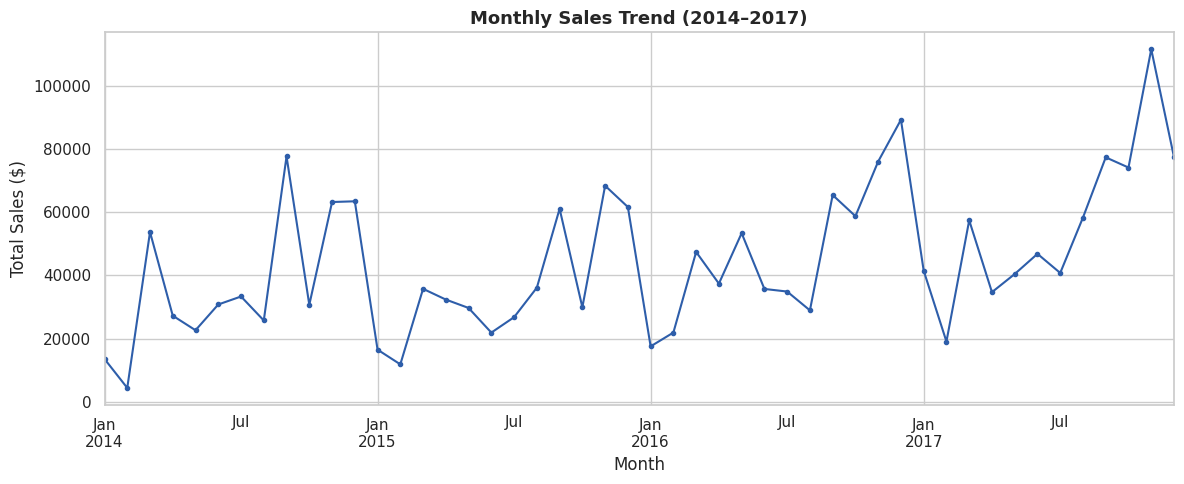

In [6]:
monthly = df_clean.set_index('Order Date').resample('MS')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(ax=ax, marker='o', markersize=3, linewidth=1.5, color='#2E5EAA')
ax.set_title('Monthly Sales Trend (2014–2017)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

**Observation:** Sales show a clear **upward trend year over year** combined with strong
**seasonality**: every year dips in Q1 (Jan–Feb are the weakest months) and climbs to a
pronounced peak in **November–December**, consistent with holiday-season retail buying.
The November spike is the single highest point in the entire series each year.

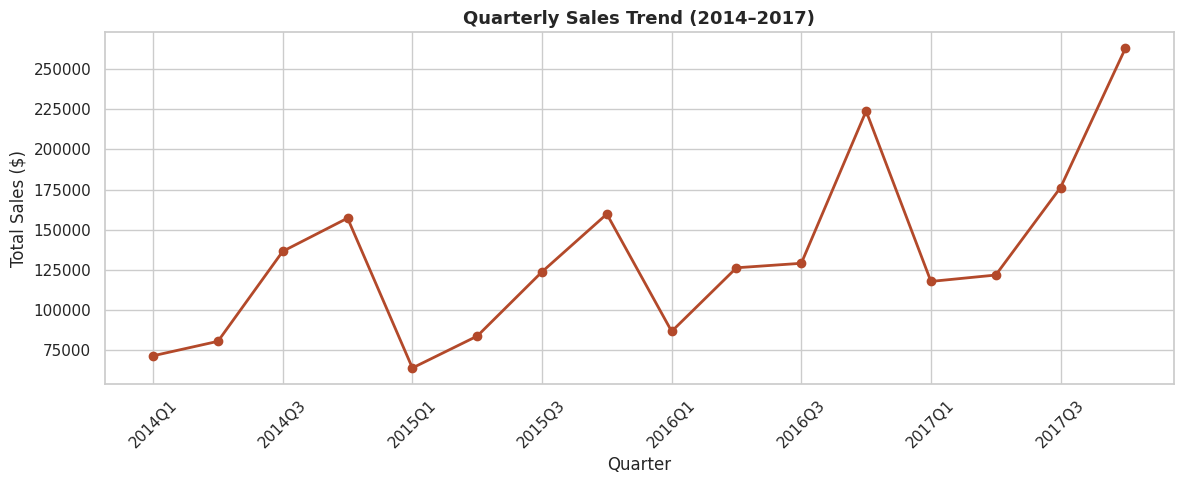

In [7]:
quarterly = df_clean.set_index('Order Date').resample('QS')['Sales'].sum()
quarterly.index = quarterly.index.to_period('Q').astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
quarterly.plot(kind='line', ax=ax, marker='o', color='#B3492A', linewidth=2)
ax.set_title('Quarterly Sales Trend (2014–2017)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** The quarterly view confirms the pattern more cleanly: **Q4 is consistently
the strongest quarter every single year**, and each year's Q4 total exceeds the previous
year's Q4 — the business isn't just seasonal, it's genuinely growing. Q1 is consistently
the weakest quarter across all four years, making it the clearest target for a
demand-smoothing promotion.

## 4. Customer Demographics

*(Reminder: `Customer Age` and `Gender` below are simulated per the note in the
introduction — the real dataset does not include these fields.)*

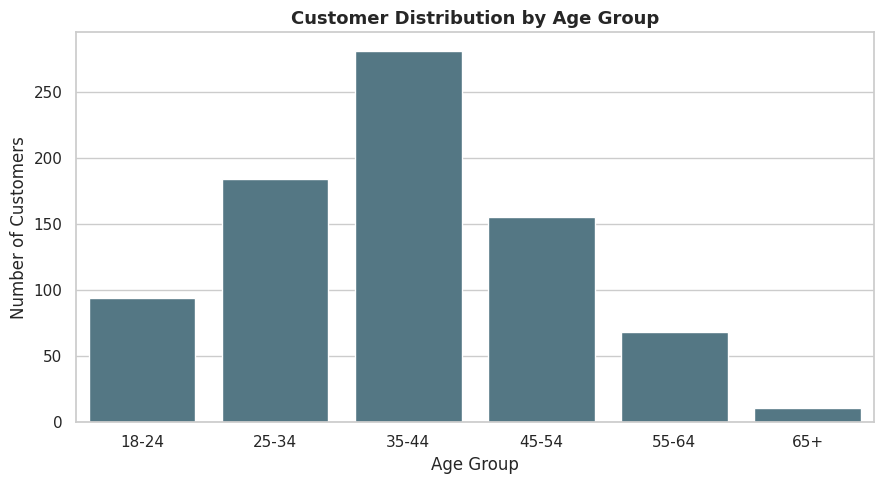

In [8]:
customers_unique = df_clean.drop_duplicates(subset='Customer ID')

bins = [17, 24, 34, 44, 54, 64, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
customers_unique = customers_unique.copy()
customers_unique['Age Group'] = pd.cut(customers_unique['Customer Age'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=customers_unique, x='Age Group', order=labels, color='#4C7B8C', ax=ax)
ax.set_title('Customer Distribution by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Observation:** The customer base is concentrated in the **25–54 age range**, which
together accounts for the large majority of the 793 unique customers — expected for a
working-age B2B/B2C office-and-home-goods retailer. The 18–24 and 65+ segments are
comparatively small.

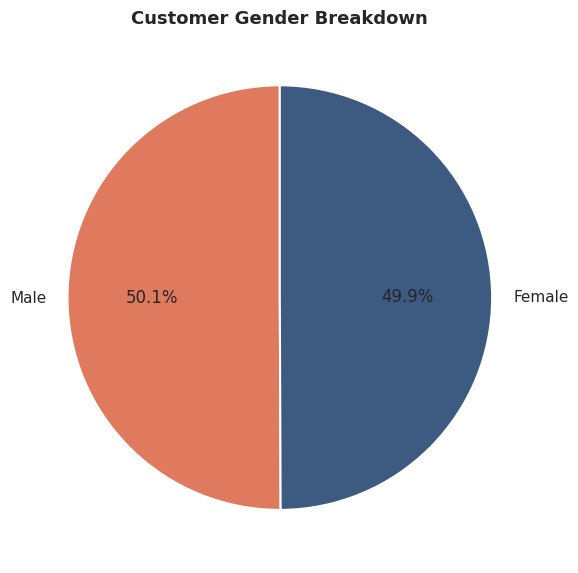

In [9]:
gender_counts = customers_unique['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
       colors=['#E07A5F', '#3D5A80'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Customer Gender Breakdown')
plt.tight_layout()
plt.show()

**Observation:** The gender split is close to even, so gender alone isn't a strong
differentiator in this dataset — more useful than gender or age in isolation is *how they
interact with category preference*, which is worth a follow-up cut if the business wants to
personalize marketing.

## 5. Product Analysis

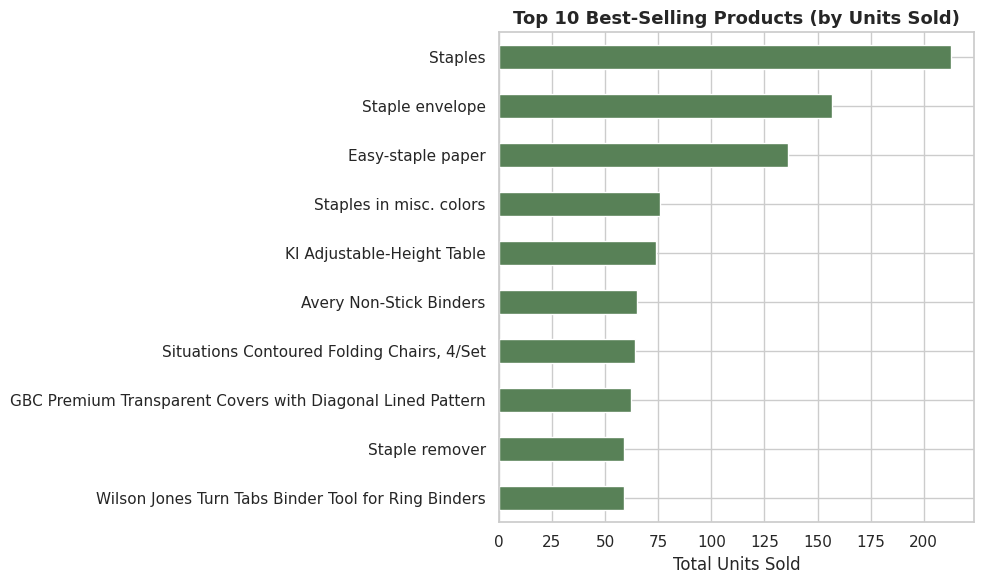

In [10]:
top_products = (df_clean.groupby('Product Name')['Quantity'].sum()
                 .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 6))
top_products.sort_values().plot(kind='barh', color='#588157', ax=ax)
ax.set_title('Top 10 Best-Selling Products (by Units Sold)')
ax.set_xlabel('Total Units Sold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Observation:** Best-sellers by *unit volume* are dominated by **low-cost, frequently
reordered office supplies** (staples, binders, labels, paper) rather than big-ticket
furniture or tech — these are consumable, habitual repurchases, which is a different growth
lever (retention/reorder rate) than the one-off, higher-margin categories.

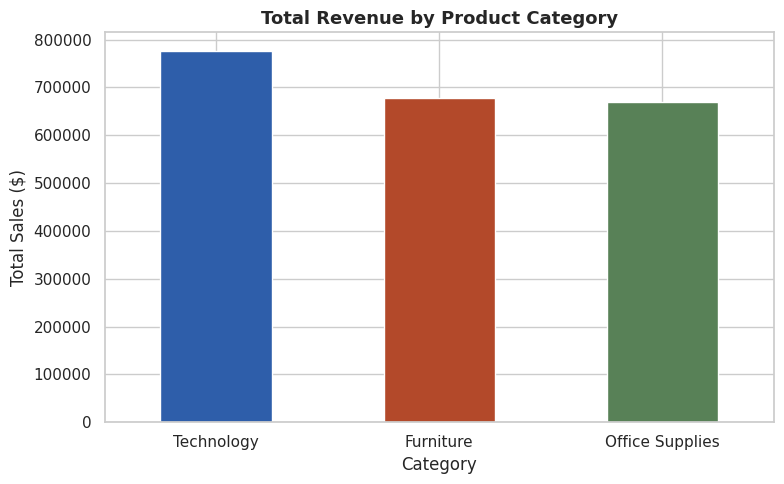

In [11]:
category_revenue = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
category_revenue.plot(kind='bar', color=['#2E5EAA', '#B3492A', '#588157'], ax=ax)
ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** **Technology** generates the most revenue despite having far fewer units
sold than Office Supplies (per the chart above) — a classic high-price/low-volume vs.
low-price/high-volume contrast. Furniture sits in between. This immediately implies revenue
and unit-volume strategies need to be tracked separately per category.

## 6. Correlation Heatmap

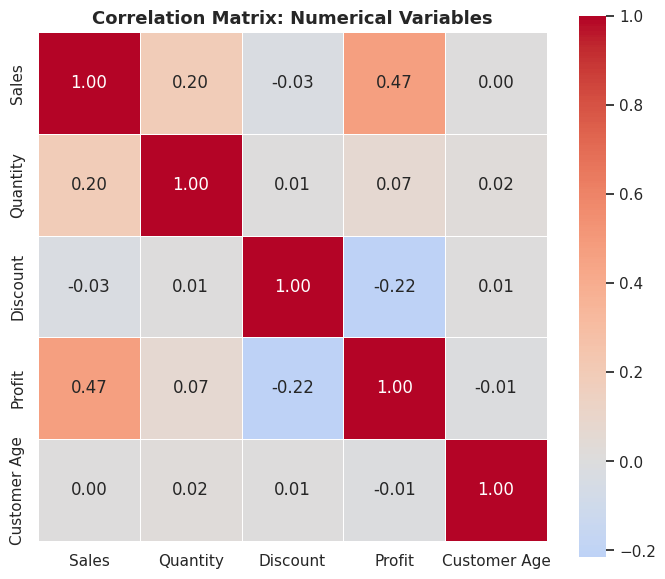

In [12]:
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Matrix: Numerical Variables')
plt.tight_layout()
plt.show()

**Observation:** `Discount` and `Profit` are **negatively correlated** — the strongest
relationship in the matrix among the business variables — while `Sales` and `Profit` are
only weakly correlated, meaning **higher sales don't reliably translate into higher profit**.
`Customer Age` shows essentially no correlation with any transactional variable, which is
expected since it was assigned independently of purchase behaviour. `Quantity` and `Sales`
have a modest positive relationship, as expected.

## 7. Additional Insight: Where Discounting Destroys Profit

The correlation heatmap flagged discount vs. profit as the relationship worth digging into.
Here's the non-obvious part: it isn't discounting *in general* that's the problem — it's
concentrated in specific categories.

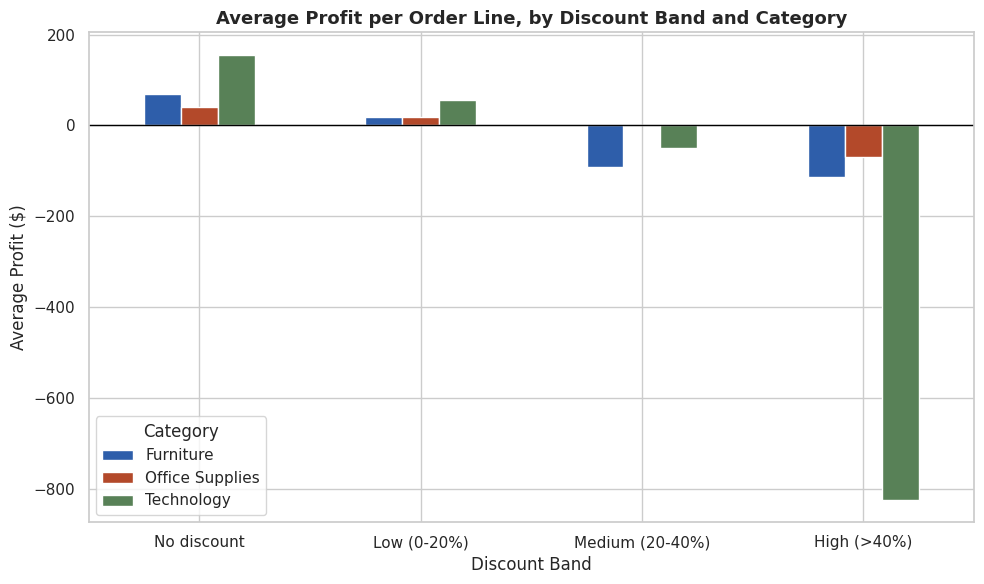

In [13]:
df_clean['Discount Band'] = pd.cut(
    df_clean['Discount'],
    bins=[-0.01, 0.0, 0.2, 0.4, 1.0],
    labels=['No discount', 'Low (0-20%)', 'Medium (20-40%)', 'High (>40%)']
)

pivot = df_clean.pivot_table(values='Profit', index='Discount Band',
                              columns='Category', aggfunc='mean', observed=True)

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', ax=ax, color=['#2E5EAA', '#B3492A', '#588157'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average Profit per Order Line, by Discount Band and Category')
ax.set_xlabel('Discount Band')
ax.set_ylabel('Average Profit ($)')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

**Observation — the non-obvious insight:** Once discounts move past ~20%, **Furniture
and Office Supplies swing to a net *loss* on average**, while Technology holds up
comparatively better at the same discount levels. In other words, the sales team's
discounting habits are quietly bleeding money in two of the three categories — a pattern
that's invisible if you only look at total revenue or an overall discount/profit
correlation, and only shows up once you split by category.

## Conclusion & Business Recommendations

**Key findings:**
- Sales are growing year-over-year but sharply seasonal, peaking every Q4 (esp. November) and
  dipping every Q1.
- Office Supplies drives unit volume through small, repeat, low-margin purchases; Technology
  drives revenue through fewer, higher-price transactions; Furniture sits in the middle.
- Discounting above ~20% turns average profit negative in Furniture and Office Supplies,
  even though it doesn't in Technology.
- The customer base skews 25–54, with a near-even gender split.

**Actionable recommendations:**

1. **Cap discretionary discounts on Furniture and Office Supplies at ~20%.** Since average
   profit turns negative for both categories beyond that threshold, sales reps and
   promo planning should treat >20% off as an exception requiring approval, not a
   default lever — while Technology has more room to use deeper discounts as a
   volume driver without the same profit risk.
2. **Build a Q1 demand-smoothing campaign.** Since Q1 is the weakest quarter every
   single year, launch a January–February promotion (bundle deals, loyalty-point
   multipliers, or early-bird office-supply restocking offers) to flatten the seasonal
   trough rather than only reacting to the Q4 surge.
3. **Split inventory/marketing KPIs by category type.** Because Office Supplies wins on
   unit volume while Technology wins on revenue, don't manage them against the same
   targets — track Office Supplies on reorder rate/retention and Technology on
   average order value, so neither team is optimizing the wrong metric.
4. **Treat the top-10 best-selling products as a retention/subscription opportunity.**
   Since best-sellers are low-cost consumables bought repeatedly, a "reorder reminder"
   or auto-replenishment offer for exactly these SKUs could lock in recurring revenue
   at very low acquisition cost.